In [65]:
from typing import TypedDict, Annotated, Literal,List, Optional
import sqlite3
import requests

from dotenv import load_dotenv
from pydantic import BaseModel,Field
from langgraph.graph import MessagesState

from langchain_core.runnables import RunnableConfig
from langchain_ollama import ChatOllama
from langchain_core.messages import BaseMessage, SystemMessage,HumanMessage
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.store.base import BaseStore
from langchain_ollama import OllamaEmbeddings
load_dotenv()
import os
import uuid


In [66]:
llm = ChatOllama(
    model="llama3.2",
    temperature=0,
    base_url="http://172.31.0.1:11434"
)


In [67]:
from langgraph.store.memory import InMemoryStore
store=InMemoryStore()


In [68]:
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored
assistance that reflects the user's preferences, context, and past interactions.

If the user's name or relevant personal context is available, always personalize your responses by:
    - Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    - Referencing known projects, tools, or preferences (e.g., "your MCP server python-based project")
    - Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible.

Use personalization especially in:
    - Greetings and transitions
    - Help or guidance tailored to tools and frameworks the user uses
    - Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user's memory (which may be empty) is provided as: {user_details_content}
"""

In [69]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

In [70]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[MemoryItem] = Field(default_factory=list, description="Atomic user memories to store")

In [71]:
memory_extractor = llm.with_structured_output(MemoryDecision)

In [72]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""

In [73]:
def remember_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]

    namespace = ("user", user_id, "details")

    # A) Load existing memories
    existing_items = store.search(namespace)
    existing_texts = [it.value.get("data", "") for it in existing_items if it.value.get("data")]
    user_details_content = "\n".join(f"- {t}" for t in existing_texts) if existing_texts else "(empty)"

    # B) Latest user message
    last_text = state["messages"][-1]

    # C) LLM extracts memories + marks new vs duplicate
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=user_details_content)),
            {"role": "user", "content": f"USER MESSAGE:\n{last_text}"},
        ]
    )

    # D) Store ONLY new memories
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace, str(uuid.uuid4()), {"data": mem.text})

    return {}

In [74]:
def chat_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    items = store.search(ns)
    user_details = "\n".join(it.value["data"] for it in items) if items else ""

    system_msg = SystemMessage(
        content=SYSTEM_PROMPT_TEMPLATE.format(
            user_details_content=user_details or "(empty)"
        )
    )

    response = llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

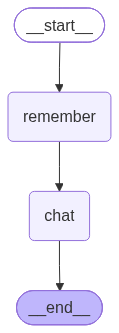

In [75]:
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_node)
builder.add_node("chat", chat_node)

builder.add_edge(START, "remember")
builder.add_edge("remember", "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [76]:
config = {"configurable": {"user_id": "u1"}}

In [77]:
r1 = graph.invoke({"messages": [{"role": "user", "content": "hello my name is sanjay "}]}, config)
print("Assistant:", r1["messages"][-1].content)

Assistant: Hello Sanjay! It's great to meet you. I'm here to help you with any questions or concerns you might have. Since we don't have much information about your preferences or projects yet, let's start fresh.

How can I assist you today, Sanjay? Are you looking for help with something specific or just want to chat?


In [78]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

Sanjay is a user.


In [79]:
r2 = graph.invoke({"messages": [{"role": "user", "content": "i love playing video games"}]}, config)
print("Assistant:", r2["messages"][-1].content)

Assistant: Sanjay, that's awesome! Video games can be such an incredible way to relax and have fun. What kind of games are you into? Are you more of a fan of action-adventure games like Assassin's Creed or The Witcher, or do you prefer something more strategic like League of Legends or Dota 2?

Also, since we don't have any specific details about your gaming preferences yet, I can suggest some popular games across various platforms that you might enjoy. Would you like me to recommend some games based on your interests?


Sanjay is a user.
